# Question 10

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

# Question 14

In [48]:
import numpy as np
import pandas as pd
from ISLP import load_data
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import \
    (LinearDiscriminantAnalysis as LDA,
     QuadraticDiscriminantAnalysis as QDA)
from ISLP import confusion_table
from ISLP.models import ModelSpec as MS
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

## (a) Create binary variable mpg01

mpg01 = 1 if mpg > median(mpg), 0 otherwise

In [49]:
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [50]:
mpg01 = [int(b) for b in Auto['mpg'] > Auto['mpg'].median()]

In [51]:
Auto['mpg01'] = mpg01

## (b) Explore graphically the association between mpg01 and other variables

In [52]:
Auto = Auto.reset_index(drop=True)
Auto.index.is_unique

True

acceleration       Axes(0.125,0.53;0.168478x0.35)
cylinders       Axes(0.327174,0.53;0.168478x0.35)
displacement    Axes(0.529348,0.53;0.168478x0.35)
horsepower      Axes(0.731522,0.53;0.168478x0.35)
mpg                Axes(0.125,0.11;0.168478x0.35)
origin          Axes(0.327174,0.11;0.168478x0.35)
weight          Axes(0.529348,0.11;0.168478x0.35)
year            Axes(0.731522,0.11;0.168478x0.35)
dtype: object

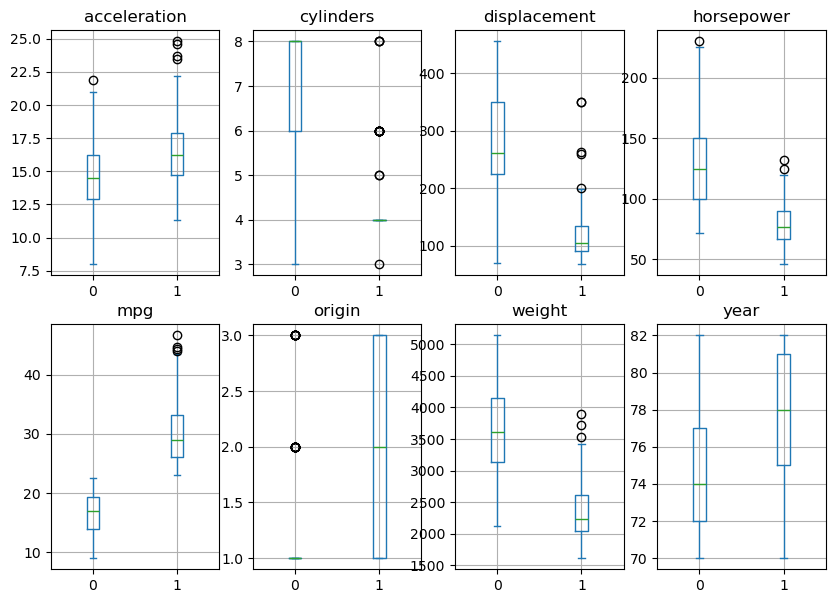

In [53]:
Auto.plot.box(by='mpg01', layout=(2,4), figsize=(10,7), grid=True)

In [54]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


The variables that seem most likely to be useful in predicting mpg01 are:

* Cylinders
* Displacement
* Horsepower
* Weight 
  
Note however each of these variables is strongly correlated with each other.

### (c) Split the data into training and test set

In [55]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'mpg01'],
      dtype='object')

In [56]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(
    Auto.drop(labels=['mpg', 'mpg01'], axis=1),
    Auto['mpg01'],
    test_size=.25,
    random_state=0
)

### (d) Linear Discriminant Analysis (LDA) using displacement and weight

In [57]:
lda = LDA(store_covariance=True)

In [58]:
train, test = [M.drop(columns=['acceleration', 'year', 'origin', 'horsepower', 'cylinders']) for M in [X_train, X_test]]

In [59]:
lda.fit(train, np.ravel(y_train))

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [60]:
lda_pred = lda.predict(test)

In [61]:
confusion_table(lda_pred, np.ravel(y_test))

Truth,0,1
Predicted,,
0,37,3
1,11,47


In [62]:
np.mean(lda_pred == np.ravel(y_test))

np.float64(0.8571428571428571)

Overall fraction of correct predictions is 86%

In [63]:
np.mean(lda_pred != np.ravel(y_test))

np.float64(0.14285714285714285)

##### Test error is 14%

### (e) Quadratic Discriminant Analysis (QDA) using displacement and weight

In [64]:
qda = QDA(store_covariance=True)
qda.fit(train, np.ravel(y_train))

,priors,None
,reg_param,0.0
,store_covariance,True
,tol,0.0001


In [65]:
qda_pred = qda.predict(test)

In [66]:
confusion_table(qda_pred, np.ravel(y_test))

Truth,0,1
Predicted,,
0,39,7
1,9,43


In [67]:
np.mean(qda_pred == np.ravel(y_test))

np.float64(0.8367346938775511)

Overall fraction of correct predictions is 84%

In [68]:
np.mean(qda_pred != np.ravel(y_test))

np.float64(0.16326530612244897)

##### Test error is 16%

#### (f) Logistic Regression using displacement and weight

In [69]:
model = MS(['displacement', 'weight']).fit(Auto)

In [70]:
logr_train = train.copy()
logr_test = test.copy()
logr_train['intercept'] = 1
logr_test['intercept'] = 1

In [71]:
glm_train = sm.GLM(np.ravel(y_train),
                   logr_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=logr_test)

In [72]:
labels = np.array([0]*98)

In [73]:
labels[probs>0.5] = 1

In [74]:
confusion_table(labels, np.ravel(y_test))

Truth,0,1
Predicted,,
0,38,7
1,10,43


In [75]:
np.mean(labels == np.ravel(y_test))

np.float64(0.826530612244898)

Overall fraction of correct predictions is 83%

In [76]:
np.mean(labels != np.ravel(y_test))

np.float64(0.17346938775510204)

##### Test error is 17%

#### (g) Naive Bayes using displacement and weight

In [77]:
NB = GaussianNB()
NB.fit(train, np.ravel(y_train))

,priors,None
,var_smoothing,1e-09


In [78]:
nb_labels = NB.predict(test)
confusion_table(nb_labels, np.ravel(y_test))

Truth,0,1
Predicted,,
0,38,6
1,10,44


In [79]:
np.mean(nb_labels == np.ravel(y_test))

np.float64(0.8367346938775511)

Overall fraction of correct predictions is 84%

In [80]:
np.mean(nb_labels != np.ravel(y_test))

np.float64(0.16326530612244897)

##### Test error is 16%

#### (h) KNN using displacement and weight and several values for K

In [81]:
def knn(X_train, L_train, X_test, L_test, k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, L_train)
    knn_pred = knn.predict(X_test)
    return confusion_table(knn_pred, L_test), np.mean(knn_pred == L_test), \
            np.mean(knn_pred != L_test)

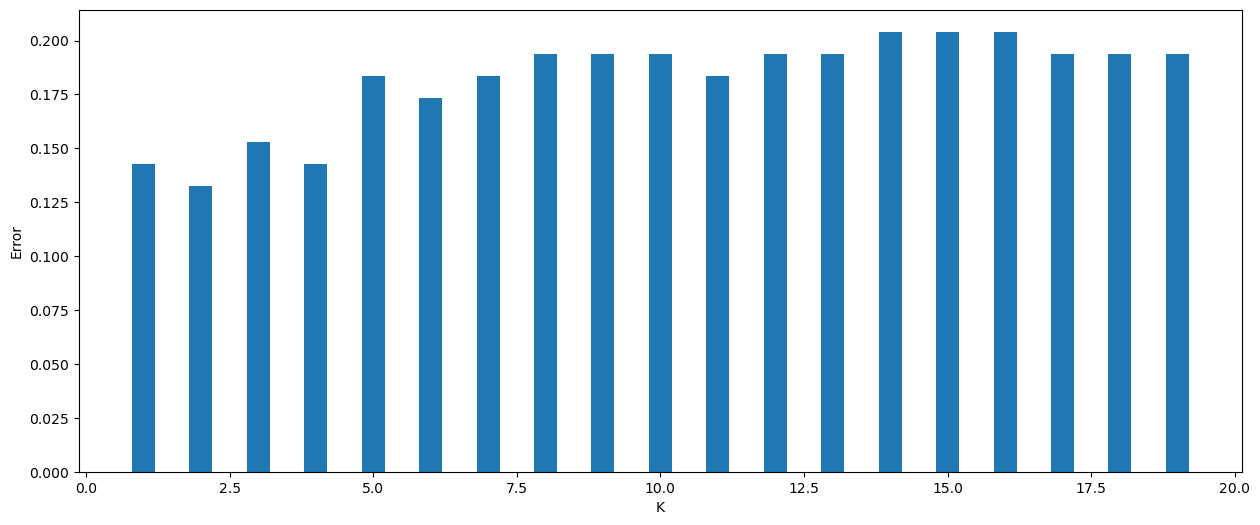

In [82]:
 # Creating bar graph
data = {}

for x in range(1, 20):
    data[x] = knn(train, np.ravel(y_train), test, np.ravel(y_test), x)[2]
    
acc = list(data.keys())
model = list(data.values())
  
fig = plt.figure(figsize = (15, 6))
plt.bar(acc, model, width = 0.4)
 
plt.xlabel("K")
plt.ylabel("Error")
plt.show()

In [83]:
confusionTable, acc, err = knn(train, np.ravel(y_train), test, np.ravel(y_test), 2)

In [84]:
confusionTable

Truth,0,1
Predicted,,
0,44,9
1,4,41


In [85]:
acc

np.float64(0.8673469387755102)

In [86]:
err

np.float64(0.1326530612244898)

K = 2 performs best on this data set with an error rate of 13%

## Question 16

crim01 = 1 if crim > median(crim), 0 otherwise

In [88]:
Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [89]:
crim01 = [int(b) for b in Boston['crim'] > Boston['crim'].median()]

In [90]:
Boston['crim01'] = crim01

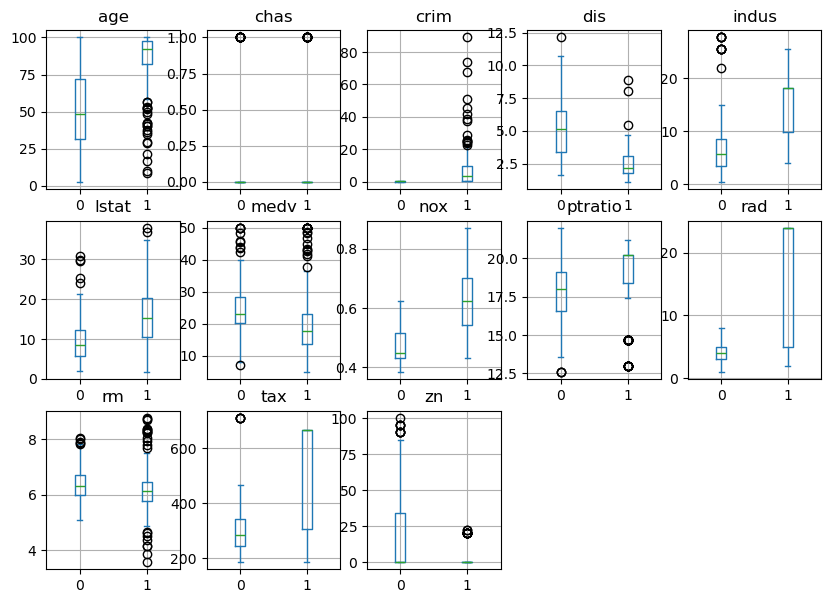

In [91]:
# Explore graphically the association between crim01 and other variables
Boston.plot.box(by='crim01', layout=(3,5), figsize=(10,7), grid=True);

In [92]:
Boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,crim01
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305,0.409395
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445,-0.436151
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725,0.603260
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260,0.070097
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321,0.723235
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360,-0.156372
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955,0.613940
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929,-0.616342
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626,0.619786
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536,0.608741


The variables that seem most likely to be useful in predicting crim01 are:

* nox
* age
* indus
* dis
* rad
* tax

#### Defining functions for pipeline

In [93]:
# Logistic Regression
def logisticRegression(X_train, y_train, X_test, L_test):
    glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
    results = glm_train.fit()
    probs = results.predict(exog=X_test)
    labels = np.array([0]*len(X_test))
    labels[probs>0.5] = 1
    return confusion_table(labels, L_test), np.mean(labels == L_test)

# lDA
def lda(X_train, L_train, X_test, L_test):
    lda = LDA(store_covariance=True)
    lda.fit(X_train, L_train)
    lda_pred = lda.predict(X_test)
    return confusion_table(lda_pred, L_test), np.mean(lda_pred == L_test)

# QDA
def qda(X_train, L_train, X_test, L_test):
    qda = QDA(store_covariance=True)
    qda.fit(X_train, L_train)
    qda_pred = qda.predict(X_test)
    return confusion_table(qda_pred, L_test), np.mean(qda_pred == L_test)

# Naive Bayes
def nb(X_train, L_train, X_test, L_test):
    NB = GaussianNB()
    NB.fit(X_train, L_train)
    nb_labels = NB.predict(X_test)
    return confusion_table(nb_labels, L_test), np.mean(nb_labels == L_test)

# KNN 
def knn(X_train, L_train, X_test, L_test, k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, L_train)
    knn_pred = knn.predict(X_test)
    return confusion_table(knn_pred, L_test), np.mean(knn_pred == L_test)

In [94]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(Boston.drop(columns=['crim01', 'crim']),
                            Boston[['crim01']],
                            test_size=.25,
                            random_state=93)

In [95]:
def compareModels(X_train, X_test, y_train, y_test):    

    data = {}

    # Logistic Regression
    logr_train = X_train.copy()
    logr_test = X_test.copy()
    logr_train['intercept'] = 1
    logr_test['intercept'] = 1
    
    logConfusionTable, accuracy = logisticRegression(logr_train, y_train, logr_test, y_test)
    data['Logistic Regression']= accuracy

    # LDA
    confusionTable, accuracy = lda(X_train, y_train, X_test, y_test)
    data['LDA']= accuracy

    # QDA
    confusionTable, accuracy = qda(X_train, y_train, X_test, y_test)
    data['QDA']= accuracy

    # Naive Bayes
    confusionTable, accuracy = nb(X_train, y_train, X_test, y_test)
    data['Naive Bayes']= accuracy

    # KNN
    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 1)
    data['KNN K=1']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 2)
    data['KNN K=2']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 5)
    data['KNN K=5']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 10)
    data['KNN K=10']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 15)
    data['KNN K=15']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 20)
    data['KNN K=20']= accuracy

    confusionTable, accuracy = knn(X_train, y_train, X_test, y_test, 25)
    data['KNN K=25']= accuracy

    # Creating bar graph
    acc = list(data.keys())
    model = list(data.values())
  
    fig = plt.figure(figsize = (15, 6))
    plt.bar(acc, model, width = 0.4)
 
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.title("Overall Fraction of Correct Predictions")
    plt.show()

    print(data)

    print('\n Max:',max(zip(data.values(), data.keys())), '\n\n', logConfusionTable)

#### Explore models using different predictors

##### Using All Variables

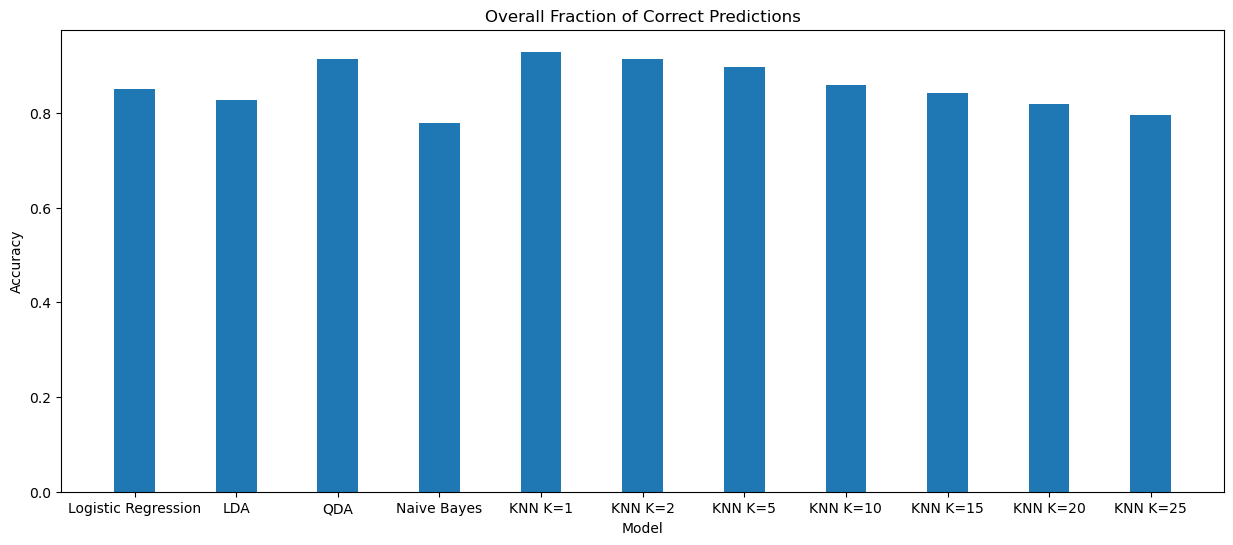

{'Logistic Regression': np.float64(0.8503937007874016), 'LDA': np.float64(0.8267716535433071), 'QDA': np.float64(0.9133858267716536), 'Naive Bayes': np.float64(0.7795275590551181), 'KNN K=1': np.float64(0.9291338582677166), 'KNN K=2': np.float64(0.9133858267716536), 'KNN K=5': np.float64(0.8976377952755905), 'KNN K=10': np.float64(0.8582677165354331), 'KNN K=15': np.float64(0.84251968503937), 'KNN K=20': np.float64(0.8188976377952756), 'KNN K=25': np.float64(0.7952755905511811)}

 Max: (np.float64(0.9291338582677166), 'KNN K=1') 

 Truth       0   1
Predicted        
0          57  11
1           8  51


In [96]:
compareModels(X_train, X_test, np.ravel(y_train), np.ravel(y_test))

#### Using nox, age, indus, dis, rad, tax

In [97]:
vars = ['nox', 'age', 'indus', 'dis', 'rad', 'tax']

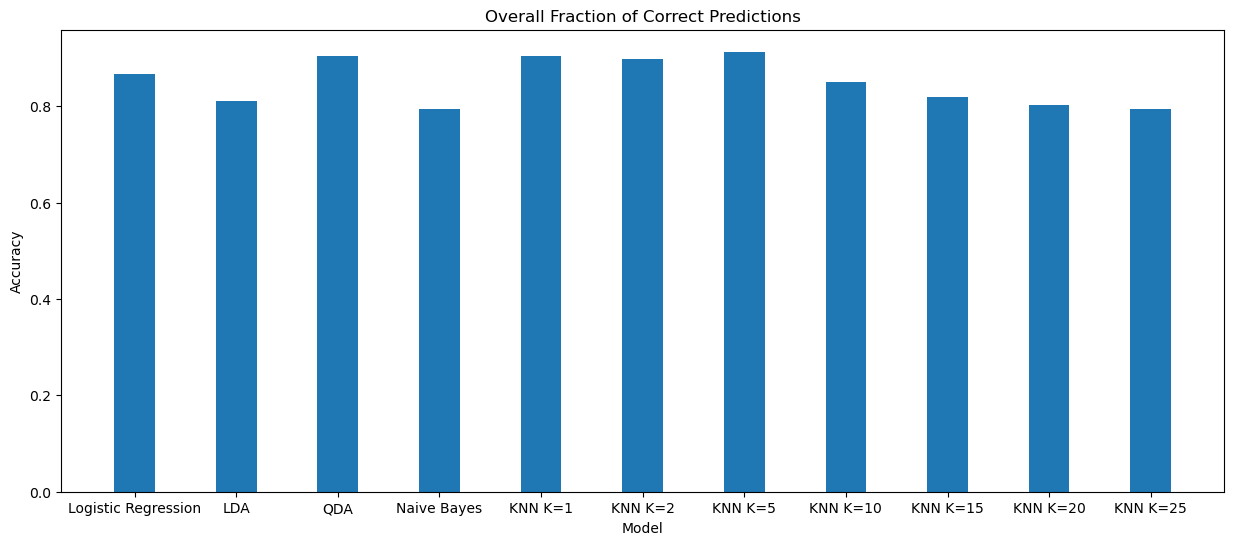

{'Logistic Regression': np.float64(0.8661417322834646), 'LDA': np.float64(0.8110236220472441), 'QDA': np.float64(0.905511811023622), 'Naive Bayes': np.float64(0.7952755905511811), 'KNN K=1': np.float64(0.905511811023622), 'KNN K=2': np.float64(0.8976377952755905), 'KNN K=5': np.float64(0.9133858267716536), 'KNN K=10': np.float64(0.8503937007874016), 'KNN K=15': np.float64(0.8188976377952756), 'KNN K=20': np.float64(0.8031496062992126), 'KNN K=25': np.float64(0.7952755905511811)}

 Max: (np.float64(0.9133858267716536), 'KNN K=5') 

 Truth       0   1
Predicted        
0          58  10
1           7  52


In [98]:
compareModels(X_train[vars], X_test[vars], np.ravel(y_train), np.ravel(y_test))

#### Using nox, rad

In [100]:
vars = ['nox', 'rad']

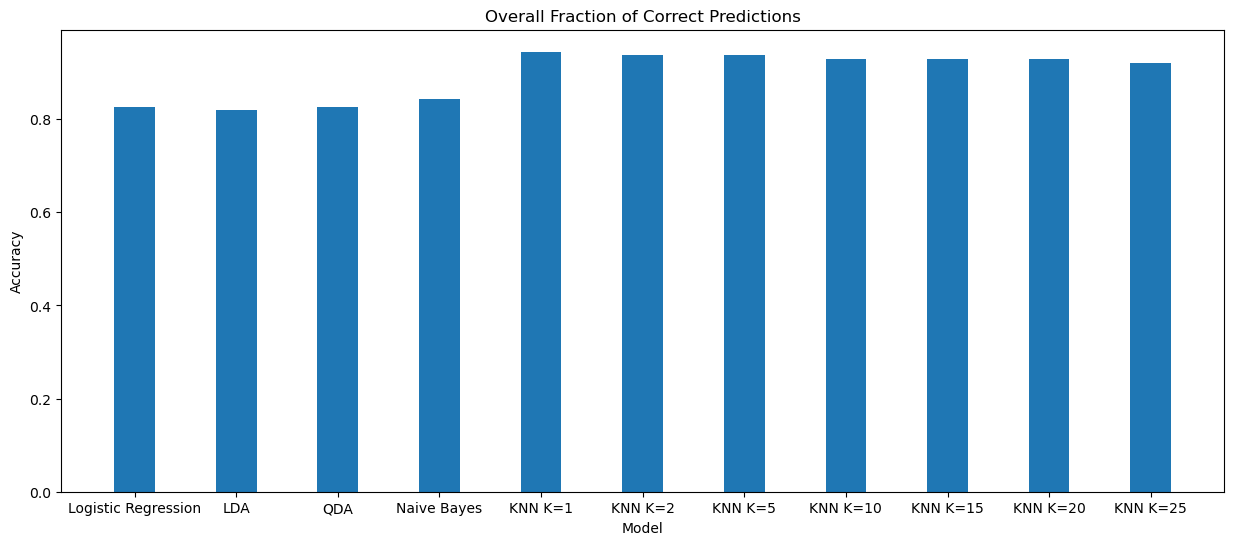

{'Logistic Regression': np.float64(0.8267716535433071), 'LDA': np.float64(0.8188976377952756), 'QDA': np.float64(0.8267716535433071), 'Naive Bayes': np.float64(0.84251968503937), 'KNN K=1': np.float64(0.9448818897637795), 'KNN K=2': np.float64(0.937007874015748), 'KNN K=5': np.float64(0.937007874015748), 'KNN K=10': np.float64(0.9291338582677166), 'KNN K=15': np.float64(0.9291338582677166), 'KNN K=20': np.float64(0.9291338582677166), 'KNN K=25': np.float64(0.9212598425196851)}

 Max: (np.float64(0.9448818897637795), 'KNN K=1') 

 Truth       0   1
Predicted        
0          57  14
1           8  48


In [101]:
compareModels(X_train[vars], X_test[vars], np.ravel(y_train), np.ravel(y_test))

#### Using nox, ptratio

In [103]:
vars = ['nox', 'ptratio']

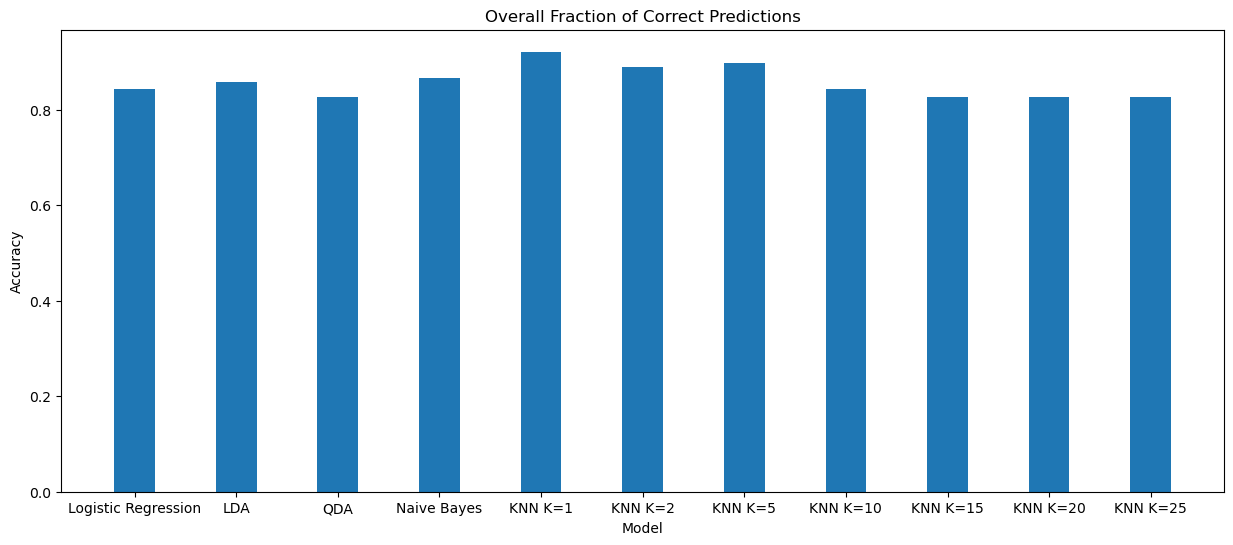

{'Logistic Regression': np.float64(0.84251968503937), 'LDA': np.float64(0.8582677165354331), 'QDA': np.float64(0.8267716535433071), 'Naive Bayes': np.float64(0.8661417322834646), 'KNN K=1': np.float64(0.9212598425196851), 'KNN K=2': np.float64(0.889763779527559), 'KNN K=5': np.float64(0.8976377952755905), 'KNN K=10': np.float64(0.84251968503937), 'KNN K=15': np.float64(0.8267716535433071), 'KNN K=20': np.float64(0.8267716535433071), 'KNN K=25': np.float64(0.8267716535433071)}

 Max: (np.float64(0.9212598425196851), 'KNN K=1') 

 Truth       0   1
Predicted        
0          57  12
1           8  50


In [104]:
compareModels(X_train[vars], X_test[vars], np.ravel(y_train), np.ravel(y_test))

#### Using rad, ptratio

In [105]:
vars = ['rad', 'ptratio']

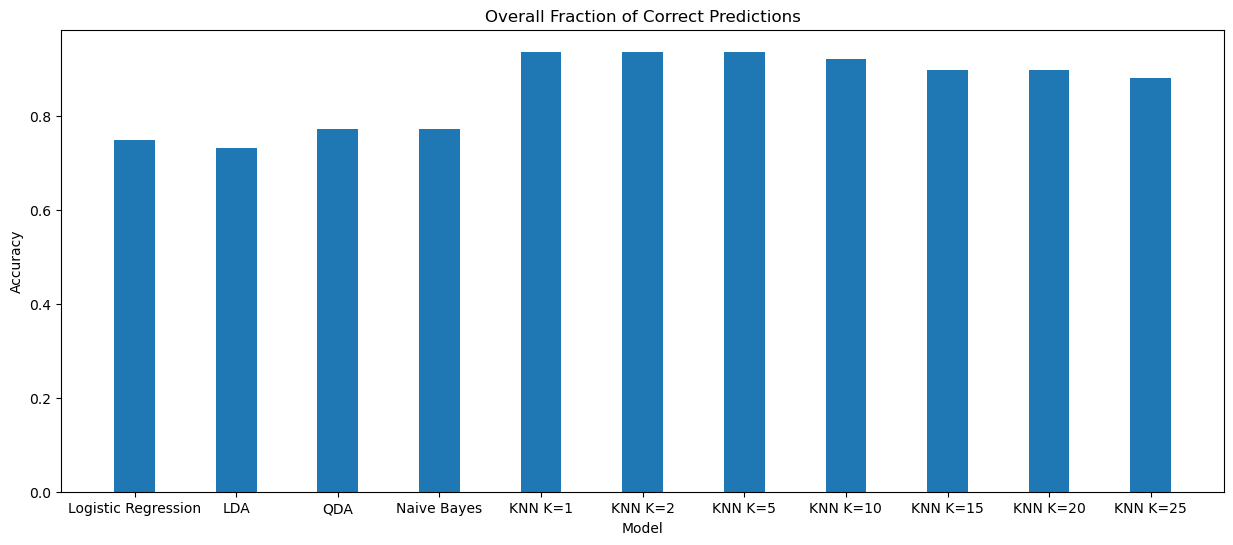

{'Logistic Regression': np.float64(0.7480314960629921), 'LDA': np.float64(0.7322834645669292), 'QDA': np.float64(0.7716535433070866), 'Naive Bayes': np.float64(0.7716535433070866), 'KNN K=1': np.float64(0.937007874015748), 'KNN K=2': np.float64(0.937007874015748), 'KNN K=5': np.float64(0.937007874015748), 'KNN K=10': np.float64(0.9212598425196851), 'KNN K=15': np.float64(0.8976377952755905), 'KNN K=20': np.float64(0.8976377952755905), 'KNN K=25': np.float64(0.8818897637795275)}

 Max: (np.float64(0.937007874015748), 'KNN K=5') 

 Truth       0   1
Predicted        
0          61  28
1           4  34


In [106]:
compareModels(X_train[vars], X_test[vars], np.ravel(y_train), np.ravel(y_test))

#### Using nox

In [108]:
vars = ['nox']

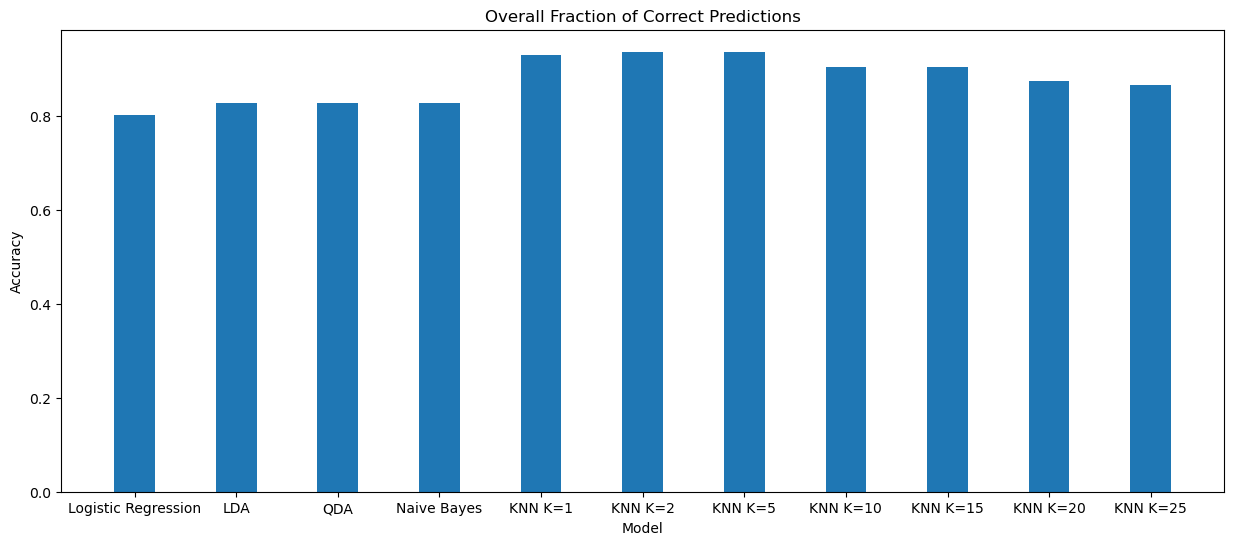

{'Logistic Regression': np.float64(0.8031496062992126), 'LDA': np.float64(0.8267716535433071), 'QDA': np.float64(0.8267716535433071), 'Naive Bayes': np.float64(0.8267716535433071), 'KNN K=1': np.float64(0.9291338582677166), 'KNN K=2': np.float64(0.937007874015748), 'KNN K=5': np.float64(0.937007874015748), 'KNN K=10': np.float64(0.905511811023622), 'KNN K=15': np.float64(0.905511811023622), 'KNN K=20': np.float64(0.8740157480314961), 'KNN K=25': np.float64(0.8661417322834646)}

 Max: (np.float64(0.937007874015748), 'KNN K=5') 

 Truth       0   1
Predicted        
0          57  17
1           8  45


In [109]:
compareModels(X_train[vars], X_test[vars], np.ravel(y_train), np.ravel(y_test))

## Best results using KNN, K = 1 with nox and rad